In [ ]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

TRAIN_DIR = '/content/drive/MyDrive/Skripsi/tomato/train'
VAL_DIR = '/content/drive/MyDrive/Skripsi/tomato/val'

# Path untuk menyimpan model terbaik hasil training
SAVE_MODEL_PATH = '/content/drive/MyDrive/skripsi/model_mobilenetv2_best.keras'

print("Path berhasil dikonfigurasi.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Path berhasil dikonfigurasi.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Konfigurasi Augmentasi untuk Data Training
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # Preprocessing bawaan MobileNetV2
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Data Validation TIDAK BOLEH diaugmentasi, hanya di-preprocess saja
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Load Data Training langsung dari folder train
print("--- Memuat Data Training ---")
train_ds = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

# Load Data Validation langsung dari folder val
print("\n--- Memuat Data Validation ---")
val_ds = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

NUM_CLASSES = train_ds.num_class_choices if hasattr(train_ds, 'num_class_choices') else len(train_ds.class_indices)
print(f"\nJumlah kelas yang terdeteksi: {NUM_CLASSES}")

--- Memuat Data Training ---
Found 10000 images belonging to 10 classes.

--- Memuat Data Validation ---
Found 1000 images belonging to 10 classes.

Jumlah kelas yang terdeteksi: 10


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import MobileNetV2

# Load base model MobileNetV2 tanpa lapisan klasifikasi teratas (include_top=False)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Bekukan bobot base model agar tidak berubah selama training awal
base_model.trainable = False

# Tambahkan lapisan klasifikasi baru khusus untuk 10 kelas tomat
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x) # Sesuai dengan hyperparameter dropout 0.2 di metodologi
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

# Gabungkan menjadi satu model utuh
model = Model(inputs=base_model.input, outputs=outputs)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Kompilasi model dengan learning rate awal (misal 0.001)
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callback untuk menghentikan training jika val_loss tidak membaik dalam 5 epoch
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Callback untuk mengunci dan menyimpan bobot terbaik (best weights) secara otomatis
checkpoint = ModelCheckpoint(
    SAVE_MODEL_PATH,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Kompilasi model dan callbacks siap digunakan.")

Kompilasi model dan callbacks siap digunakan.


In [ ]:
# Jalankan proses training
EPOCHS = 15

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print(f"\nTraining Selesai! Model terbaik Anda telah disimpan secara fisik di: {SAVE_MODEL_PATH}")

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.5609 - loss: 1.2915
Epoch 1: val_accuracy improved from None to 0.74700, saving model to /content/drive/MyDrive/skripsi/model_mobilenetv2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/skripsi/model_mobilenetv2_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 201s 592ms/step - accuracy: 0.6920 - loss: 0.9048 - val_accuracy: 0.7470 - val_loss: 0.7311
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.8027 - loss: 0.5783
Epoch 2: val_accuracy improved from 0.74700 to 0.77800, saving model to /content/drive/MyDrive/skripsi/model_mobilenetv2_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/skripsi/model_mobilenetv2_best.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 173s 554ms/step - accuracy: 0.8091 - loss: 0.5536 - val_accuracy: 0.7780 - val_loss: 0.6746
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.8305 - loss: 0.4784
Epoch 3: val_accuracy improved from 0.77800

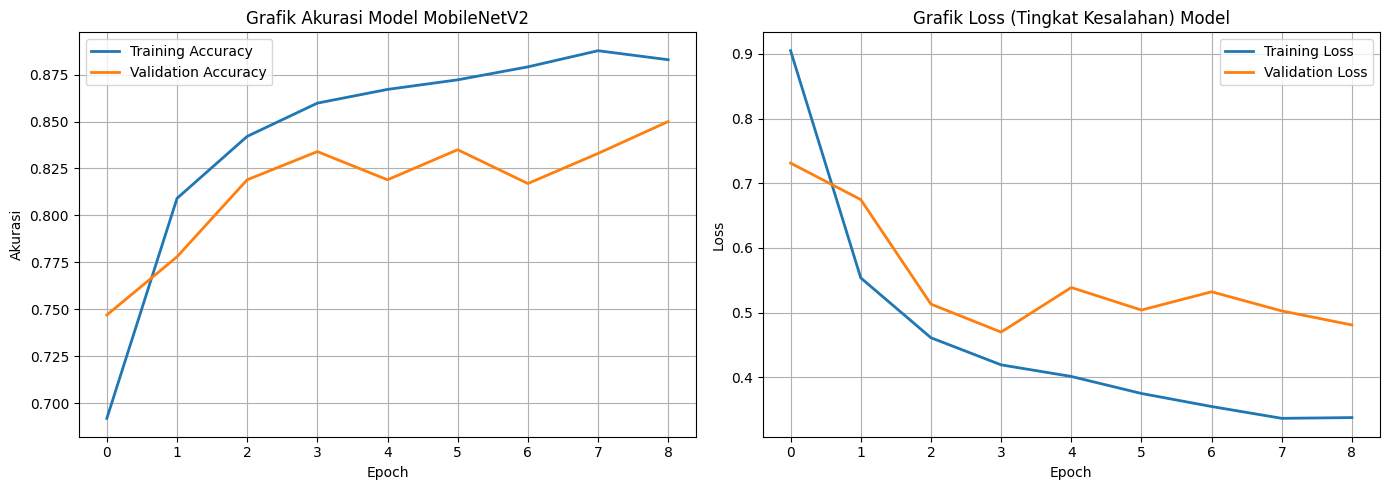


--- Memproses Evaluasi Data Validation ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 344ms/step

Laporan Klasifikasi (Classification Report):
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot     0.9405    0.7900    0.8587       100
                        Tomato___Early_blight     0.8857    0.6200    0.7294       100
                         Tomato___Late_blight     0.8378    0.9300    0.8815       100
                           Tomato___Leaf_Mold     0.7965    0.9000    0.8451       100
                  Tomato___Septoria_leaf_spot     0.7542    0.8900    0.8165       100
Tomato___Spider_mites Two-spotted_spider_mite     0.8300    0.8300    0.8300       100
                         Tomato___Target_Spot     0.7255    0.7400    0.7327       100
       Tomato___Tomato_Yellow_Leaf_Curl_Virus     0.9894    0.9300    0.9588       100
                 Tomato___Tomato_mosaic_virus     0.8372    0.7200    0.7742       1

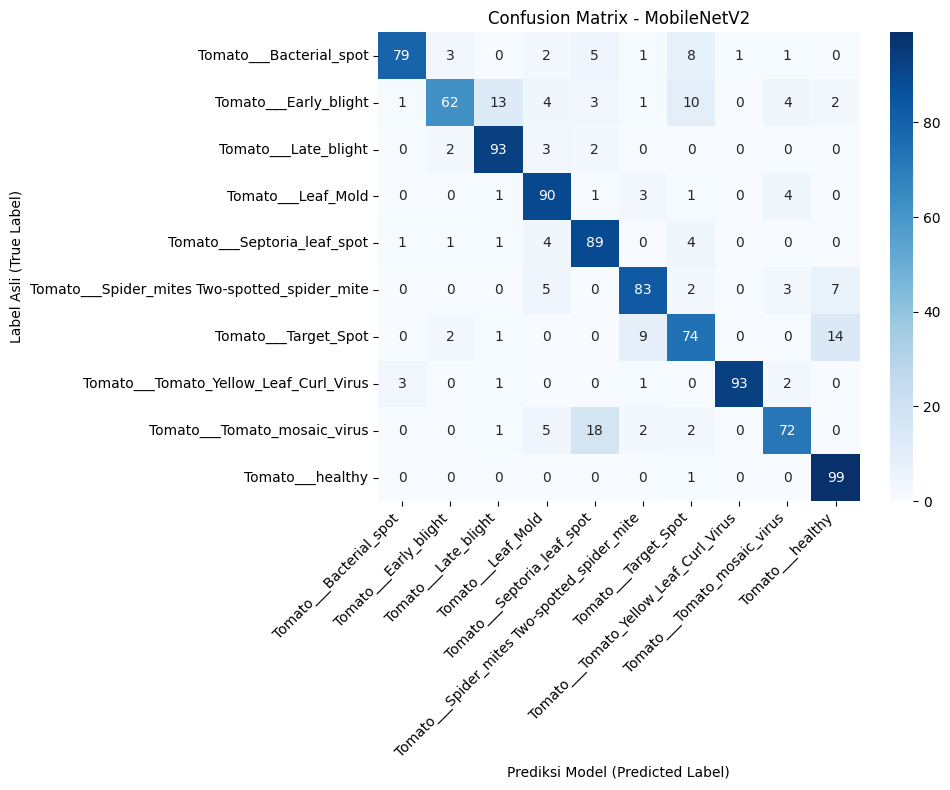

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Deteksi otomatis key yang digunakan oleh Keras (mencegah KeyError)
keys = history.history.keys()
acc_key = 'accuracy' if 'accuracy' in keys else 'acc'
val_acc_key = 'val_accuracy' if 'val_accuracy' in keys else 'val_acc'
loss_key = 'loss'
val_loss_key = 'val_loss'


# 1. GRAFIK RIWAYAT PELATIHAN (ACCURACY & LOSS)

plt.figure(figsize=(14, 5))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history[acc_key], label='Training Accuracy', linewidth=2)
plt.plot(history.history[val_acc_key], label='Validation Accuracy', linewidth=2)
plt.title('Grafik Akurasi Model MobileNetV2')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True)

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(history.history[loss_key], label='Training Loss', linewidth=2)
plt.plot(history.history[val_loss_key], label='Validation Loss', linewidth=2)
plt.title('Grafik Loss (Tingkat Kesalahan) Model')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# 2. EVALUASI METRIK & CONFUSION MATRIX

print("\n--- Memproses Evaluasi Data Validation ---")
val_ds.reset() # Reset generator agar urutannya pas
Y_pred = model.predict(val_ds, verbose=1)
y_pred = np.argmax(Y_pred, axis=1)
y_true = val_ds.classes

# Ambil nama-nama kelas penyakit
class_names = list(val_ds.class_indices.keys())

# Cetak Tabel Metrik (Accuracy, Precision, Recall, F1-Score)
print("\nLaporan Klasifikasi (Classification Report):")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Cetak Confusion Matrix berwarna
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - MobileNetV2')
plt.ylabel('Label Asli (True Label)')
plt.xlabel('Prediksi Model (Predicted Label)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


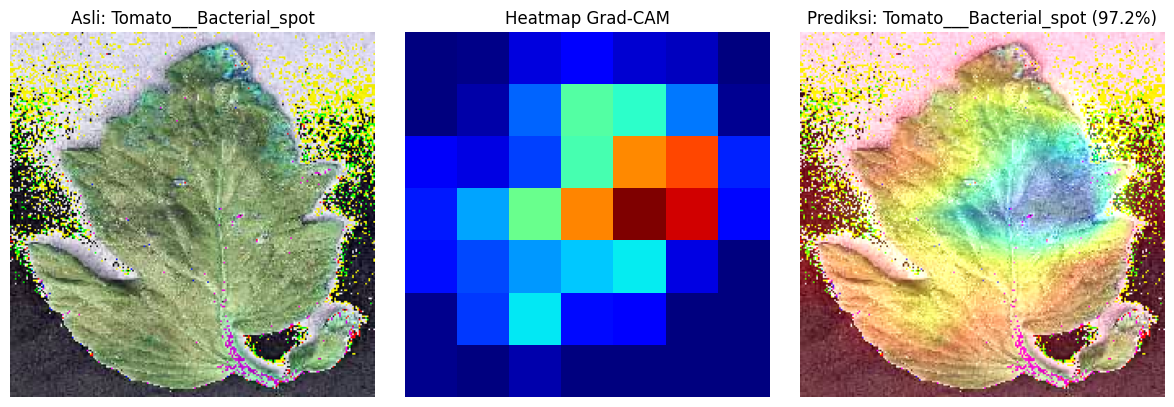

In [ ]:
import cv2
import matplotlib.cm as cm

# Nama layer terakhir untuk arsitektur MobileNetV2 di Keras
LAST_CONV_LAYER = 'out_relu'

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Ambil satu gambar contoh dari Validation Set yang sudah di-load di Sel 7
img_array = val_images[0:1]
actual_label_index = np.argmax(val_labels[0])
actual_class = class_names[actual_label_index]

# Prediksi menggunakan model
preds = model.predict(img_array)
pred_label_index = np.argmax(preds[0])
pred_class = class_names[pred_label_index]
confidence = preds[0][pred_label_index] * 100

# Buat Heatmap
heatmap = make_gradcam_heatmap(img_array, model, LAST_CONV_LAYER)

# Visualisasi Gabungan
img_original = (img_array[0] * 255).astype("uint8") if np.max(img_array) <= 1.0 else img_array[0].astype("uint8")
img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB) # Pastikan warna daun hijau alami

heatmap_resized = cv2.resize(heatmap, (img_original.shape[1], img_original.shape[0]))
heatmap_resized = np.uint8(255 * heatmap_resized)
heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)

superimposed_img = heatmap_colored * 0.4 + img_original
superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')

# Plot Hasilnya
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_original)
plt.title(f"Asli: {actual_class}")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title("Heatmap Grad-CAM")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img)
plt.title(f"Prediksi: {pred_class} ({confidence:.1f}%)")
plt.axis('off')

plt.tight_layout()
plt.show()